В текущем проекте мы взяли датасет с платформы Kaggle с данными о клиентах мобильного оператора. В нем представлена информация: о личных данных клиента (есть партнер, иждивенцы, (не)пожилой), о технической возможности подключения к услугам, о подключенных услугах, срок подключения, типа договора/оплаты и отказался или нет клиент от продолжения договора.

Для начала нам нужно прочитать и посмотреть на данные, затем привести их к удобному для анализа виду. 

Далее приступим к поиску закономерностей и причин оттока, выявим наиболее стабильные категории клиентов и приносящие больше всего денег (сегментация пользователей, АBC-анализ).



# EDA-анализ на примере датасета Неизвестного Телеком-оператора
## Чтение и преобразование файла

In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.reset_defaults()
plt.style.use('default')
# from scipy import stats
# from scipy.stats import binom, norm

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)
%matplotlib inline

In [161]:
df = pd.read_csv('../datasets/customer_churn.csv', delimiter=',', encoding='utf-8')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [162]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [163]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [164]:
# смотрим, какие можно привести к числовому формату или категории

for col in df.columns[1:]:
    if len(df[col].unique()) == 2:
        print(f'{col}:',* df[col].unique())


gender: Female Male
SeniorCitizen: 0 1
Partner: Yes No
Dependents: No Yes
PhoneService: No Yes
PaperlessBilling: Yes No
Churn: No Yes


In [165]:
# приводим к числовому формату, убрав пробелы для точного совпадения
# числовой формат понадобится для построения матрицы корреляций и для облегчения расчетов в будущем
mapping = {'Yes': 1, 'No': 0}
for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies']:
    df[col] = df[col].apply(lambda x: x.strip()).map(mapping)

df['TotalCharges'] = df['TotalCharges'].apply(lambda x: x.strip()).apply(lambda x: float(x) if x else 0.0)

In [166]:
# mapping = {1:'Yes', 0:'No'}
# df['SeniorCitizen'] = df['SeniorCitizen'].map(mapping)
# df['SeniorCitizen'] = df['SeniorCitizen'].astype('category')

In [167]:
# приводим к типу categories, чтобы экономить память
types = {i: 'category' for i in ['gender',
                                 'MultipleLines', 'InternetService',  'Contract', 'PaymentMethod']}
df = df.astype(types)


## Поиск корреляций, визуализация

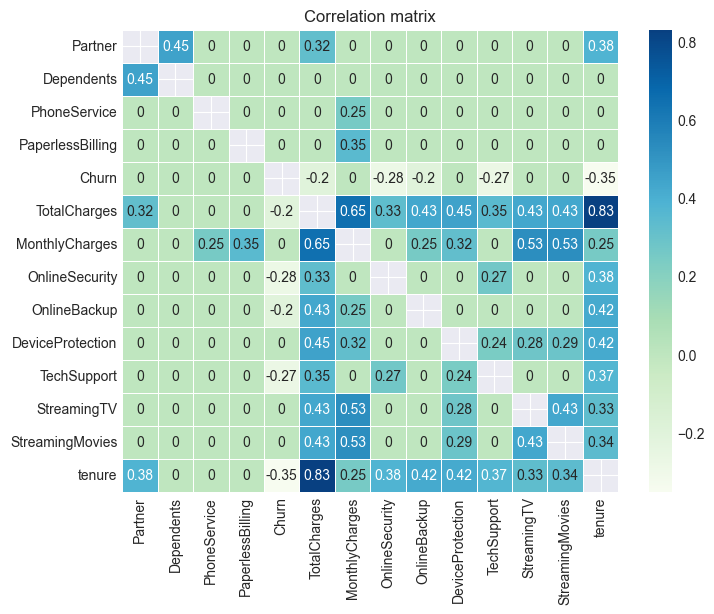

In [168]:
plt.figure(figsize=(8, 6))

# sns.set_style(font_scale=1.4)
df1 = df[['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn', 'TotalCharges', 'MonthlyCharges', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'tenure']]
mask = np.eye(df1.corr().shape[0], dtype=bool)
# display(mask)
corr_matrix = df1.corr()
corr_matrix = np.round(corr_matrix, 2)
corr_matrix[np.abs(corr_matrix) < 0.2] = 0 #убираем слабую корреляцию,чтобы не перегружать график

sns.heatmap(corr_matrix, annot=True, linewidths=.5, cmap='GnBu', mask=mask)

plt.title('Correlation matrix')
plt.show()

Положительная корреляция:
 - сильная корреляцию подключенных пакетов услуг и увеличения общей выручки, при этом на месячную оплату влияют не все услуги.
 - наличия партнера и иждивенцев и увеличение общих расходов при наличии партнера. 
 - безбумажные счета и увеличение месячных трат -- автопродление и автооплату сложнее контролировать, поэтому логично увеличение трат.
 - на срок подписки влияет наличие партнера.

Отрицательная корреляция:
 - наличие техподдержки и услуг защиты уменьшает отток. 
 - отток снижается с увеличением срока подписки

In [169]:
df_person = df[['Partner', 'Dependents', 'gender', 'TotalCharges', 'MonthlyCharges', 'SeniorCitizen', 'tenure']].copy()
df_person.head()

,Partner,Dependents,gender,TotalCharges,MonthlyCharges,SeniorCitizen,tenure
0,1,0,Female,29.85,29.85,0,1
1,0,0,Male,1889.50,56.95,0,34
2,0,0,Male,108.15,53.85,0,2
3,0,0,Male,1840.75,42.30,0,45
4,0,0,Female,151.65,70.70,0,2


In [170]:
mapping = {1:'Yes', 0:'No'}
for col in ['Partner', 'Dependents', 'SeniorCitizen']:
    df_person[col] = df_person[col].map(mapping)
df_person.head()

,Partner,Dependents,gender,TotalCharges,MonthlyCharges,SeniorCitizen,tenure
0,Yes,No,Female,29.85,29.85,No,1
1,No,No,Male,1889.50,56.95,No,34
2,No,No,Male,108.15,53.85,No,2
3,No,No,Male,1840.75,42.30,No,45
4,No,No,Female,151.65,70.70,No,2


<Figure size 1200x1000 with 0 Axes>

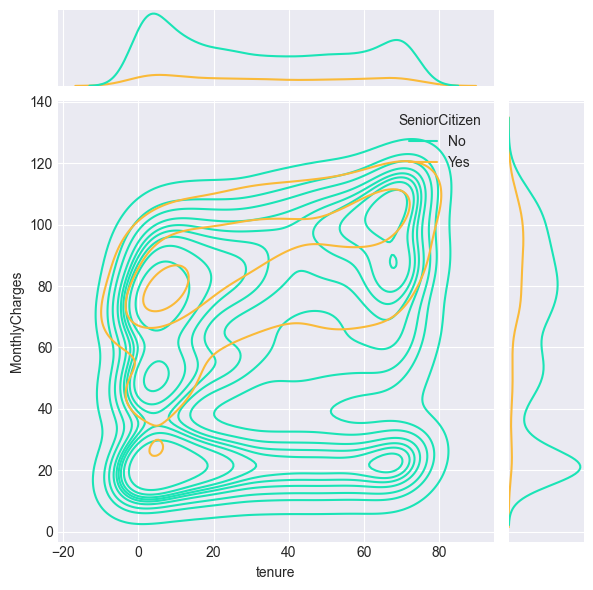

In [171]:
plt.figure(figsize=(12,10))
sns.jointplot(data=df_person, x='tenure', y='MonthlyCharges', hue='SeniorCitizen', kind='kde', palette='turbo', #xlim=(0,80), ylim=(0,130)
              )
plt.show();

<Figure size 1200x1000 with 0 Axes>

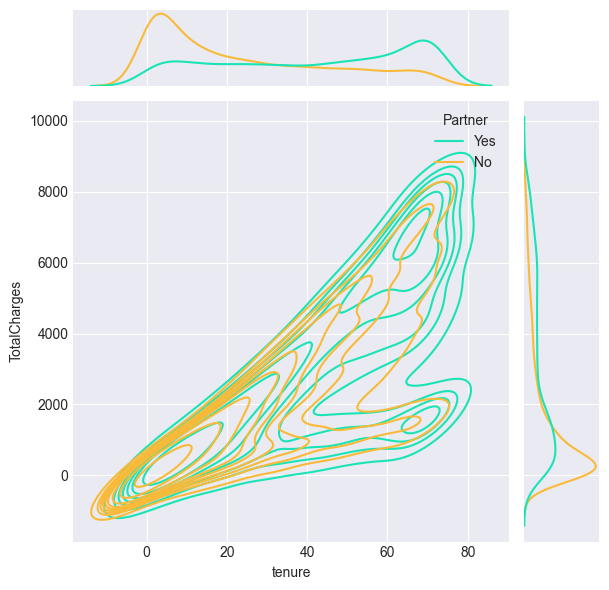

In [172]:
plt.figure(figsize=(12,10))
sns.jointplot(data=df_person, x='tenure', y='TotalCharges', hue='Partner', kind='kde', palette='turbo', #xlim=(0,80), ylim=(0,130)
              )

plt.show();

<Figure size 1200x1000 with 0 Axes>

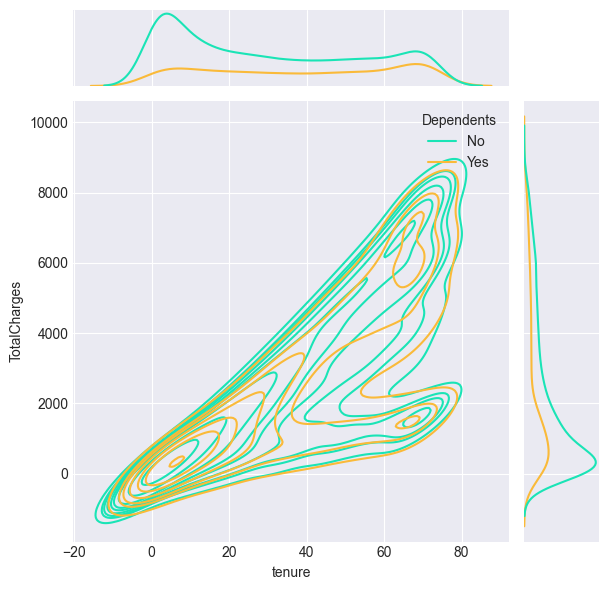

In [173]:
plt.figure(figsize=(12,10))
sns.jointplot(data=df_person, x='tenure', y='TotalCharges', hue='Dependents', kind='kde', palette='turbo', #xlim=(0,80), ylim=(0,130)
              )

plt.show();


Влияния срока подписки на ежемесячную оплату не наблюдается, однако заметно, что пожилые тратят меньше.

Сравним траты по разным категориям: пол, возраст, семейный статус, наличие иждивенцев.

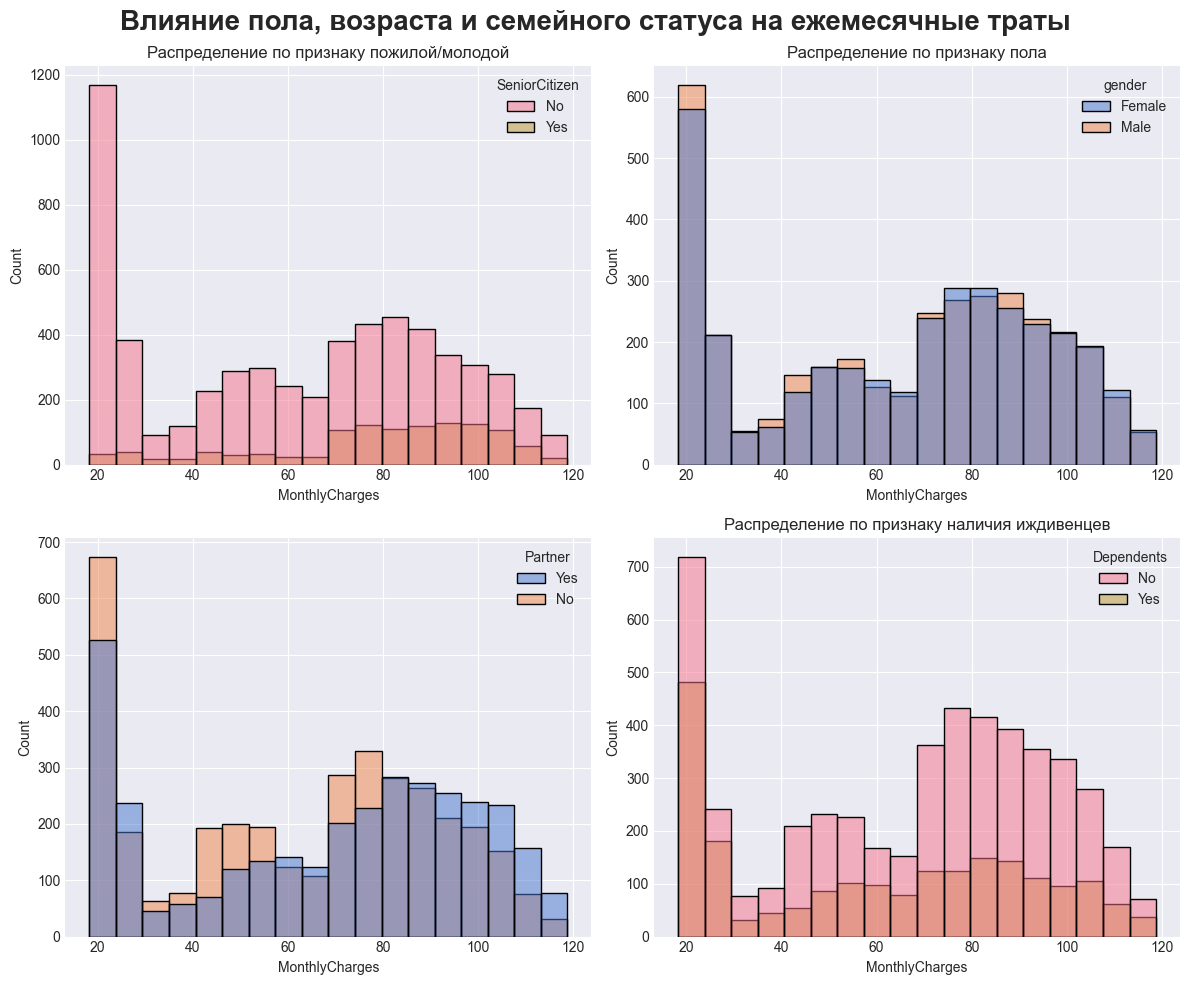

In [174]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(12,10))
sns.histplot(data=df_person, x='MonthlyCharges', hue='SeniorCitizen', ax=ax1)
plt.suptitle('Влияние пола, возраста и семейного статуса на ежемесячные траты', fontsize=20, fontweight='bold')
ax1.set_title('Распределение по признаку пожилой/молодой')

sns.histplot(data=df_person, x='MonthlyCharges', hue='gender', ax=ax2, palette='muted')
ax2.set_title('Распределение по признаку пола')

sns.histplot(data=df_person, x='MonthlyCharges', hue='Partner', ax=ax3, palette='muted')
ax4.set_title('Распределение по признаку наличия партнера')

sns.histplot(data=df_person, x='MonthlyCharges', hue='Dependents', ax=ax4)
ax4.set_title('Распределение по признаку наличия иждивенцев')

plt.tight_layout()
plt.show()

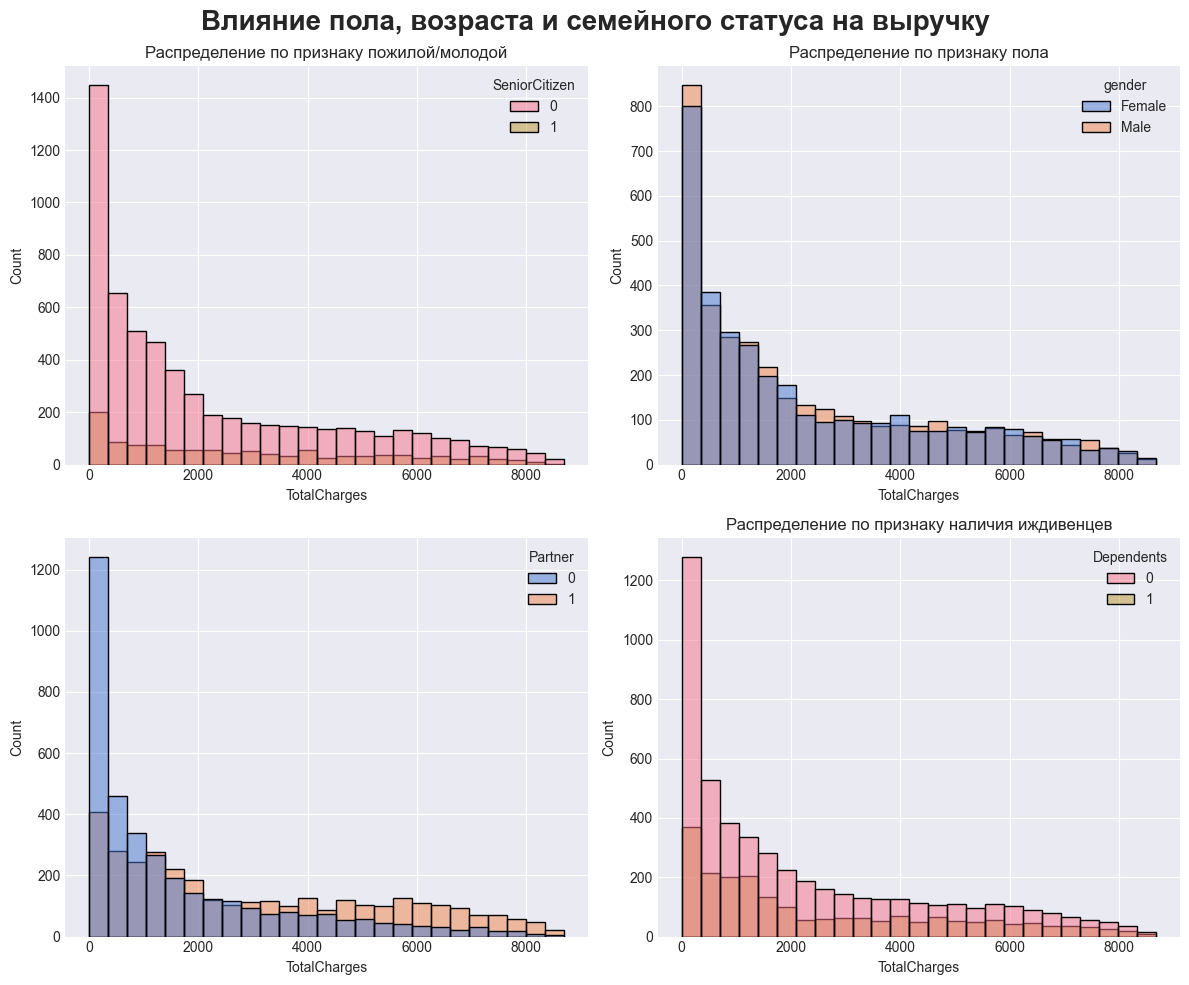

In [175]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(12,10))
sns.histplot(data=df, x='TotalCharges', hue='SeniorCitizen', ax=ax1)
plt.suptitle('Влияние пола, возраста и семейного статуса на выручку', fontsize=20, fontweight='bold')
ax1.set_title('Распределение по признаку пожилой/молодой')

sns.histplot(data=df, x='TotalCharges', hue='gender', ax=ax2, palette='muted')
ax2.set_title('Распределение по признаку пола')

sns.histplot(data=df, x='TotalCharges', hue='Partner', ax=ax3, palette='muted')
ax4.set_title('Распределение по признаку наличия партнера')

sns.histplot(data=df, x='TotalCharges', hue='Dependents', ax=ax4)
ax4.set_title('Распределение по признаку наличия иждивенцев')

plt.tight_layout()
plt.show()

In [176]:
family = pd.crosstab(index=df['Dependents'], columns=df_person['Partner'], values=df_person['MonthlyCharges'], aggfunc='median')
display(family)

Partner,No,Yes
Dependents,,
0,69.7,81.4
1,50.1,65.0


Наличие партнера увеличивает траты, даже не смотря на то, что наличие иждивенцев их уменьшает!

In [177]:
payment = pd.crosstab(
    df['Contract'], df['PaymentMethod'],
    values=df['Churn'],
    aggfunc='sum', normalize=True
)*100
print('% Оттока в разрезе формы оплаты и срока договора')
display(payment.round(1))

% Оттока в разрезе формы оплаты и срока договора


PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Contract,,,,
Month-to-month,10.8,9.5,53.2,15.1
One year,2.0,2.2,3.4,1.2
Two year,1.0,0.7,0.7,0.2


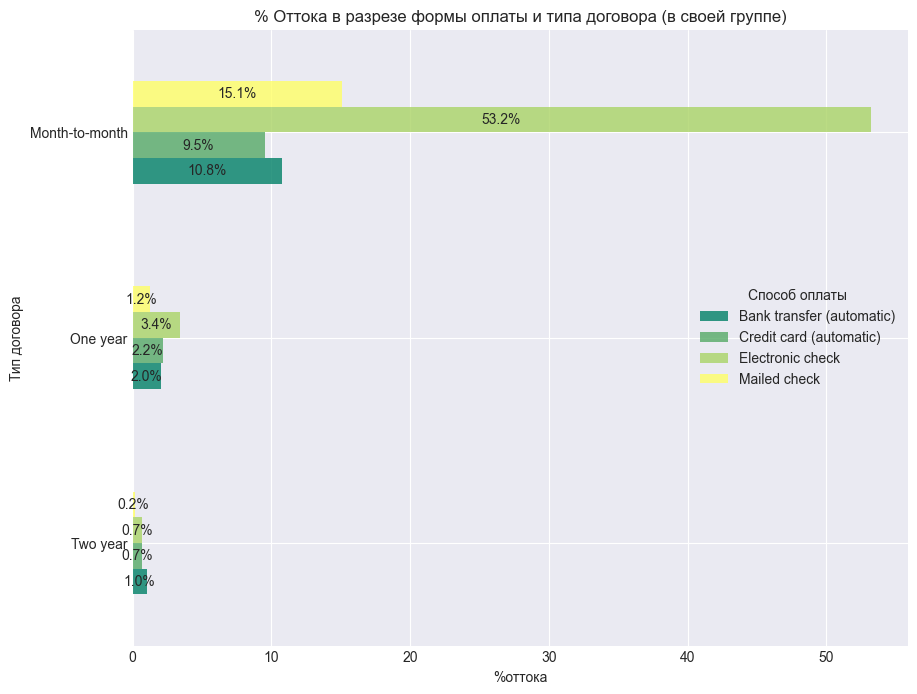

In [178]:
order = ['Two year', 'One year', 'Month-to-month']

ax = payment.reindex(order).plot(kind='barh',
                  ylabel='Тип договора', xlabel='%оттока',
                  figsize=(10,8), alpha=0.8, colormap='summer', rot=0)

ax.legend(loc='center right', title='Способ оплаты')
plt.title('% Оттока в разрезе формы оплаты и типа договора (в своей группе)')
# Добавление подписей внутри/над столбцами
for p in ax.containers:
    ax.bar_label(p, label_type='center', fmt='%1.1f%%') # 'edge' - над, 'center' - внутри

plt.show()

# ABC-анализ и сегментация пользователей в разрезе LTV (TotalCharges).

## Подготовим данные

In [179]:
# Выделим столбцы с id клиента и суммой, потраченной каждым клиентом
df_abc = df[['customerID', 'TotalCharges']].copy()
df_abc.head()

,customerID,TotalCharges
0,7590-VHVEG,29.85
1,5575-GNVDE,1889.50
2,3668-QPYBK,108.15
3,7795-CFOCW,1840.75
4,9237-HQITU,151.65


In [180]:
# сортируем total charges по убыванию
df_abc = df_abc.sort_values('TotalCharges', ascending=False).reset_index(drop=True)
# посчитаем общую выручку компании, долю каждого клиента от общей выручки
total_revenue = df_abc['TotalCharges'].sum()
df_abc['revenue_share'] = df_abc['TotalCharges'] / total_revenue * 100
#  считаем накопленную долю каждого клиента
df_abc['cumulative_share'] = df_abc['revenue_share'].cumsum()

df_abc.head()

,customerID,TotalCharges,revenue_share,cumulative_share
0,2889-FPWRM,8684.80,0.054090,0.054090
1,7569-NMZYQ,8672.45,0.054013,0.108103
2,9739-JLPQJ,8670.10,0.053999,0.162102
3,9788-HNGUT,8594.40,0.053527,0.215629
4,8879-XUAHX,8564.75,0.053342,0.268971


In [181]:
# теперь нужно присвоить категорию АВС: А = 0-80%, В = 80-95%, С = 95-100%
def assign_abc_mark(cumulative_sum):
    return 'A' if cumulative_sum <= 80 else ('B' if cumulative_sum <= 95 else 'C')

df_abc['abc_mark'] = df_abc['cumulative_share'].apply(assign_abc_mark)

# Проверим распределение
print(df_abc['abc_mark'].value_counts())

abc_mark
A    2701
C    2649
B    1693
Name: count, dtype: int64


## Визуализируем кривую Паретто

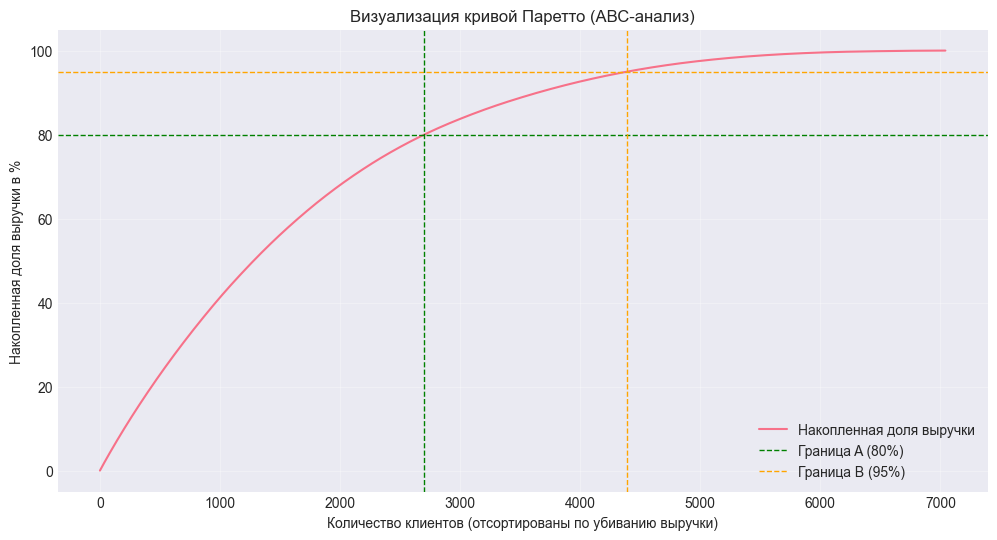

In [182]:
plt.figure(figsize=(12,6))
plt.plot(df_abc.index, df_abc['cumulative_share'], label='Накопленная доля выручки')
# Добавляем горизонтальные и вертикальные линии для границ A, B, C
plt.axhline(y=80, color='green', linestyle='--', linewidth=1, label='Граница A (80%)')
plt.axhline(y=95, color='orange', linestyle='--', linewidth=1, label='Граница B (95%)')

# Находим примерные границы по оси X (количество клиентов)
limit_a = df_abc[df_abc['cumulative_share'] <= 80].index.max()
limit_b = df_abc[df_abc['cumulative_share'] <= 95].index.max()

plt.axvline(x=limit_a, color='green', linestyle='--', linewidth=1)
plt.axvline(x=limit_b, color='orange', linestyle='--', linewidth=1)

plt.xlabel('Количество клиентов (отсортированы по убиванию выручки)')
plt.ylabel('Накопленная доля выручки в %')
plt.title('Визуализация кривой Паретто (АВС-анализ)')

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [183]:
# теперь посмотрим на цифры, сколько клиентов составляют каждую группу и какой процент выручки
group_stats = df_abc.groupby('abc_mark').agg(
    total_revenue = ('TotalCharges', 'sum'),
    customer_count = ('customerID', 'count')
).reset_index()
# теперь посчитаем доли на соответствие закону Паретто
group_stats['revenue_share_%'] = round(group_stats['total_revenue'] / group_stats['total_revenue'].sum()*100, 2)
group_stats['customer_share_%'] = round(group_stats['customer_count'] / group_stats['customer_count'].sum() * 100,2)

group_stats


,abc_mark,total_revenue,customer_count,revenue_share_%,customer_share_%
0,A,12843549.90,2701,79.99,38.35
1,B,2409543.15,1693,15.01,24.04
2,C,803075.65,2649,5.00,37.61


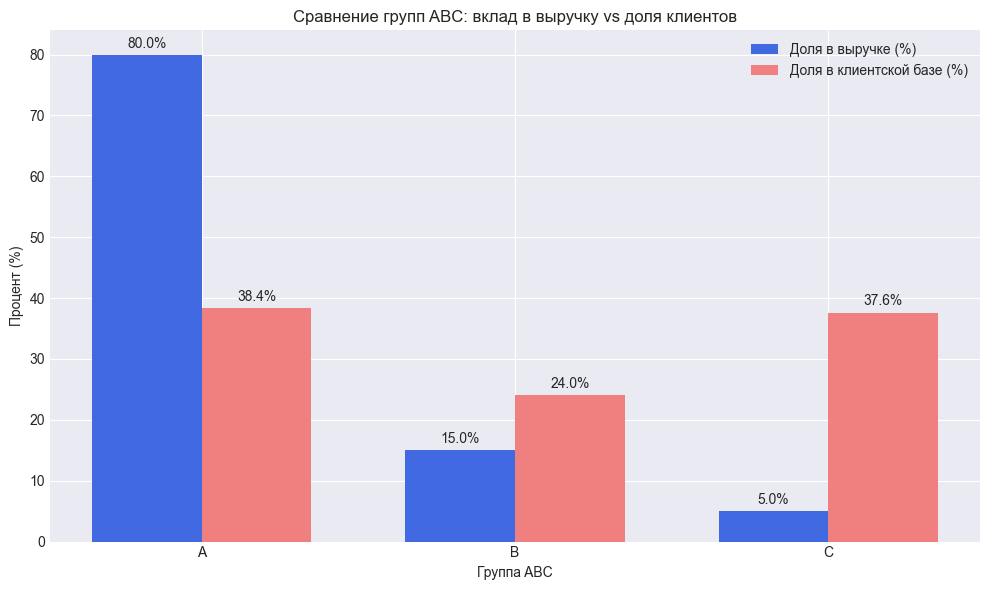

In [184]:
# Строим двойную столбчатую диаграмму
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(group_stats['abc_mark']))
width = 0.35

# Столбцы для доли выручки и доли клиентов
bars1 = ax.bar(x - width/2, group_stats['revenue_share_%'], width, label='Доля в выручке (%)', color='royalblue')
bars2 = ax.bar(x + width/2, group_stats['customer_share_%'], width, label='Доля в клиентской базе (%)', color='lightcoral')

# Добавляем подписи
ax.set_xlabel('Группа ABC')
ax.set_ylabel('Процент (%)')
ax.set_title('Сравнение групп ABC: вклад в выручку vs доля клиентов')
ax.set_xticks(x)
ax.set_xticklabels(group_stats['abc_mark'])
ax.legend()
ax.bar_label(bars1, padding=3, fmt='%.1f%%')
ax.bar_label(bars2, padding=3, fmt='%.1f%%')

plt.tight_layout()
plt.show()

In [185]:
df = df.merge(df_abc[['customerID', 'abc_mark']], how='left', on='customerID')

churn_by_abc = df.groupby('abc_mark')['Churn'].agg(['sum', 'mean', 'count'])
churn_by_abc['mean'] = churn_by_abc['mean'] * 100

print("Отток по группам ABC:")
print(churn_by_abc.round(2))

Отток по группам ABC:
           sum   mean  count
abc_mark                    
A          492  18.22   2701
B          374  22.09   1693
C         1003  37.86   2649


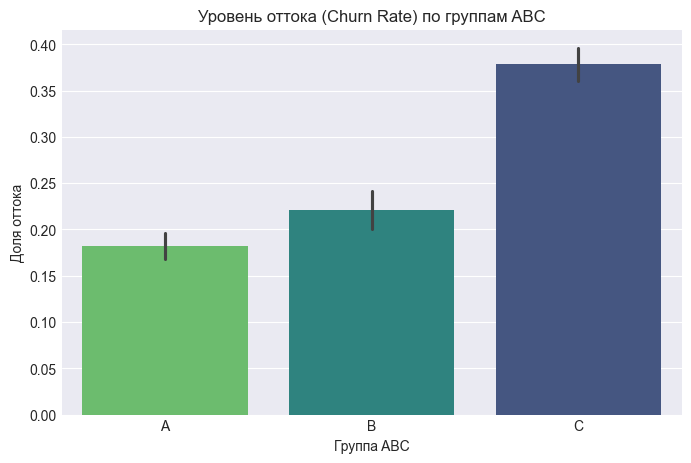

In [186]:
# Визуализируем отток
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='abc_mark', y='Churn', order=['A', 'B', 'C'], hue='abc_mark', palette='viridis')
plt.title('Уровень оттока (Churn Rate) по группам ABC')
plt.ylabel('Доля оттока')
plt.xlabel('Группа ABC')
plt.show()

### Интерпретация результата
Группа А, приносящая 80% прибыли компании и составляющая ~ 40% ее аудитории -- наиболее устойчива к оттоку, доля оттока менее 20%

### Составим "портрет" группы А

In [187]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'abc_mark'],
      dtype='str')

In [188]:
a_group = df[df['abc_mark']=='A'].copy()

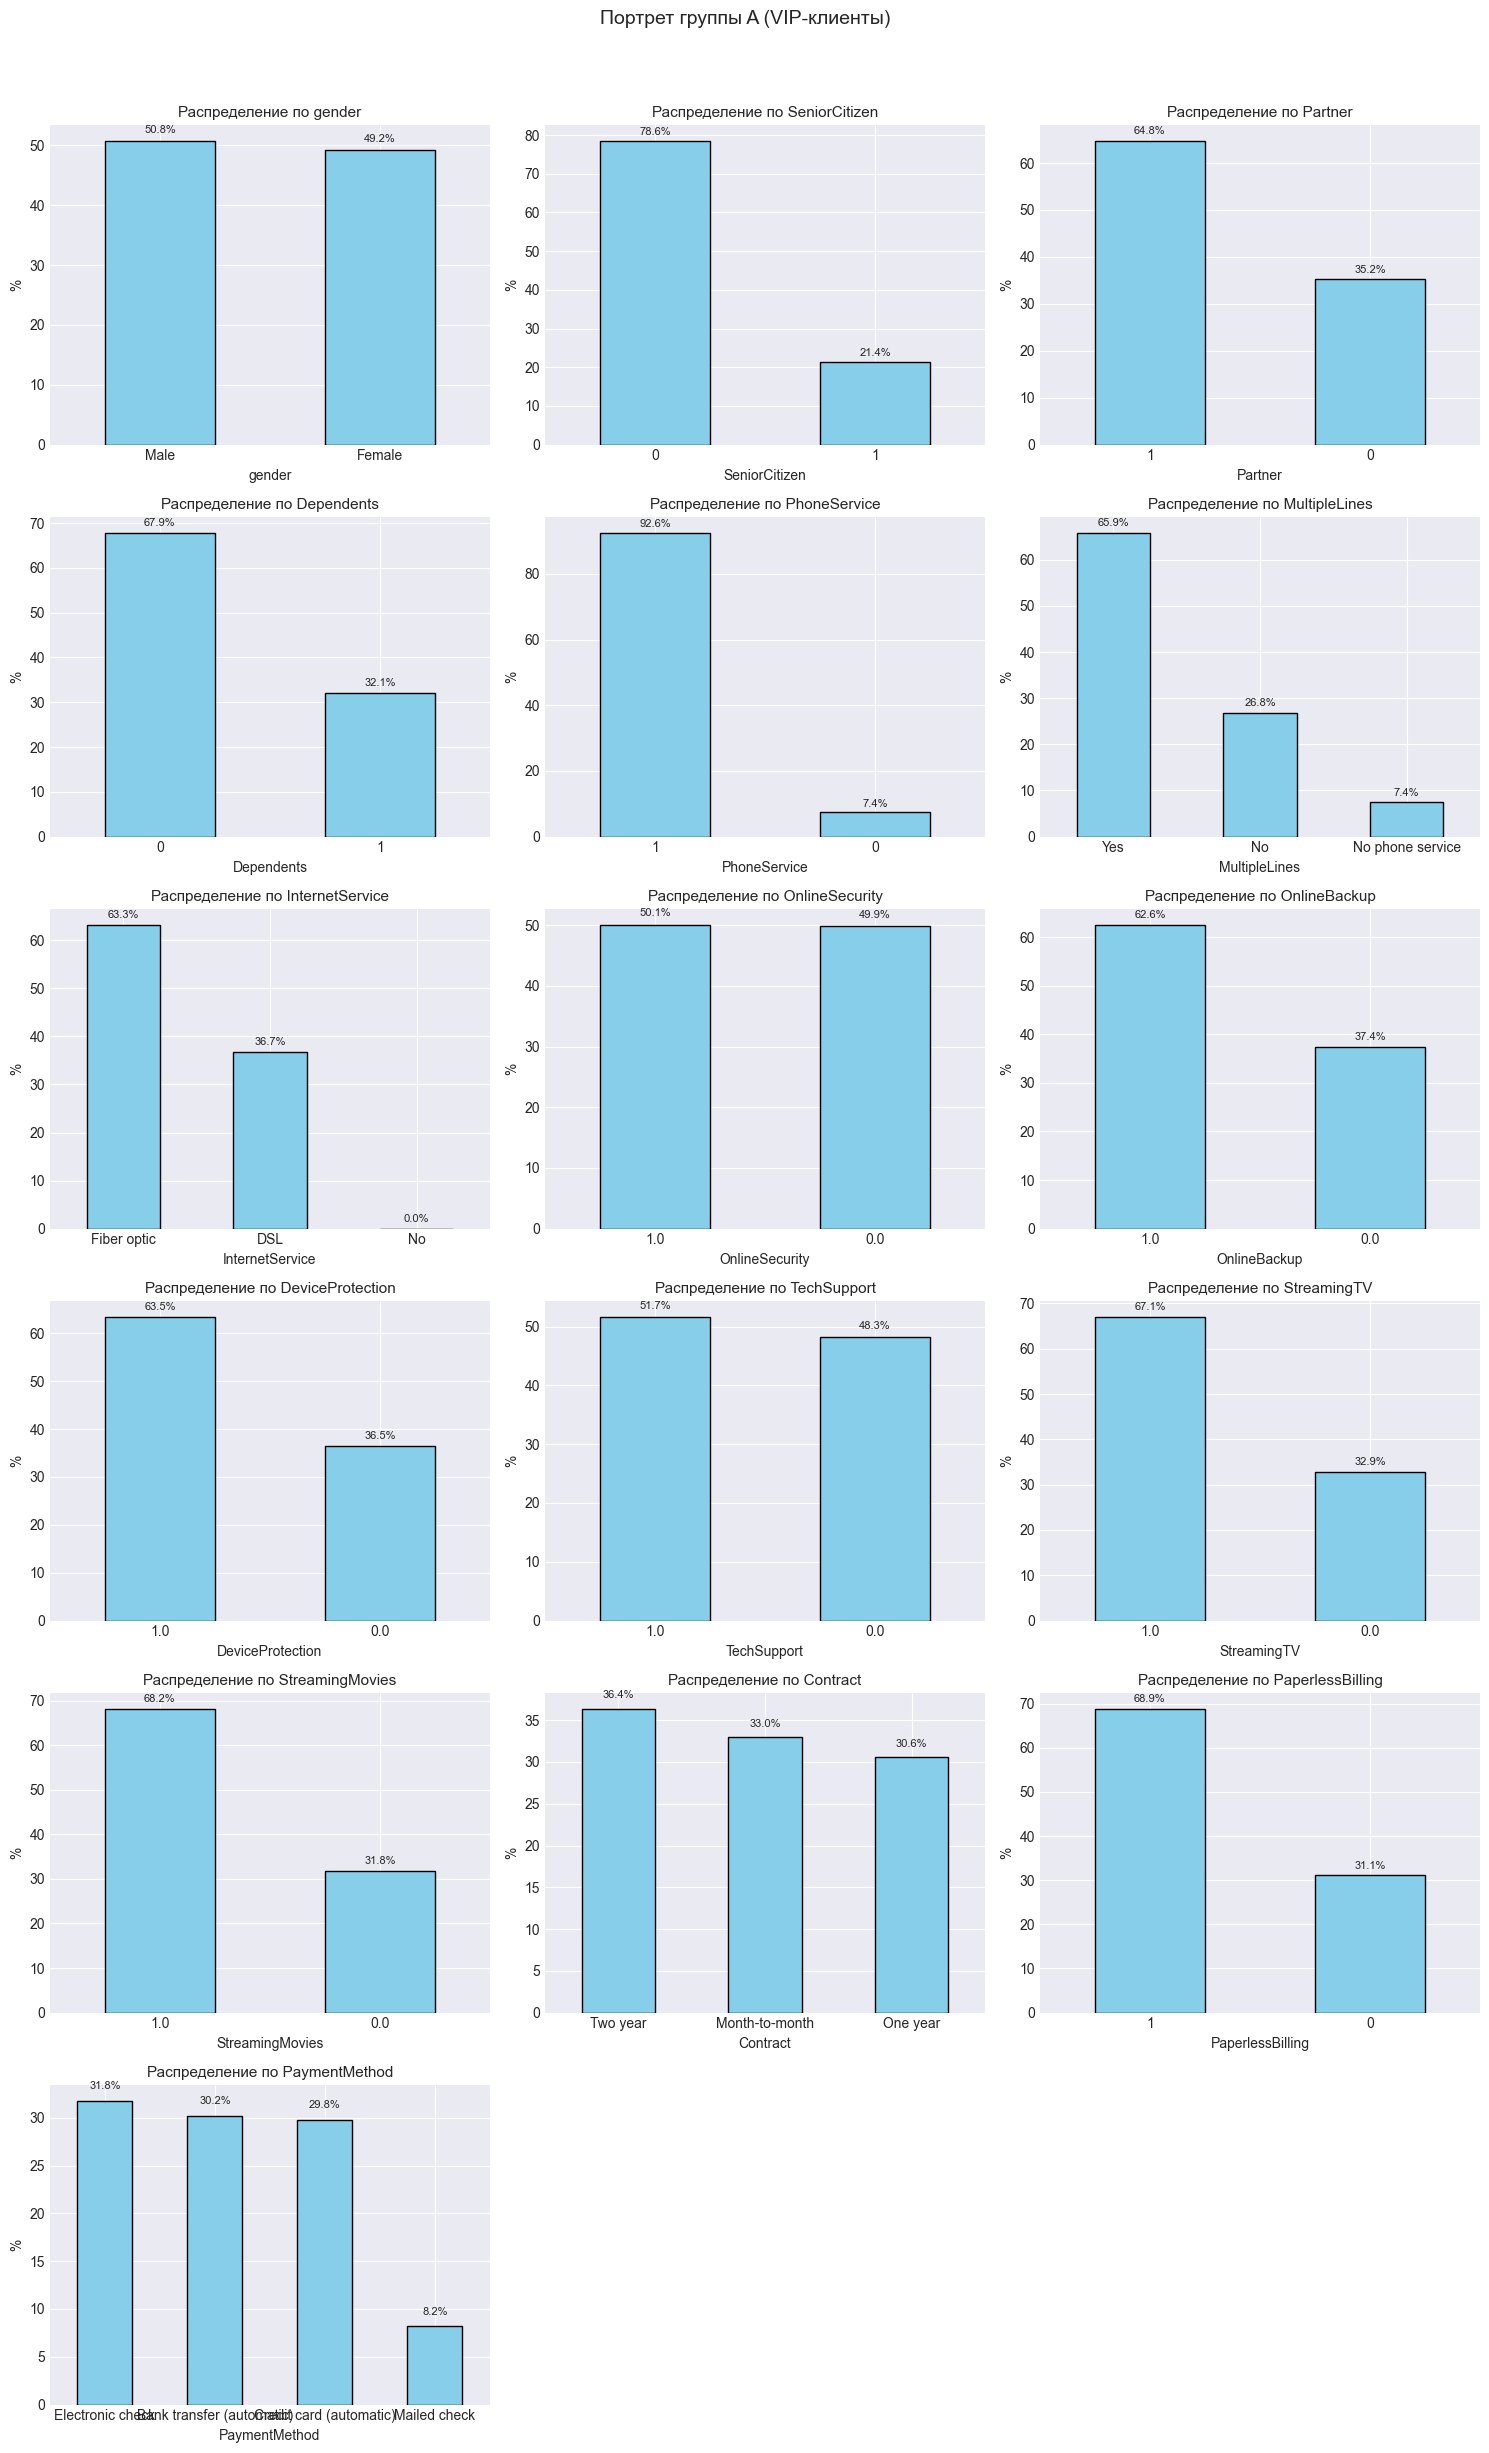

In [189]:
import matplotlib.pyplot as plt
import seaborn as sns

# Выделяем группу A
a_group = df[df['abc_mark'] == 'A'].copy()

# Список категориальных признаков для анализа
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

# Создаём сетку графиков
n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for idx, col in enumerate(cat_cols):
    # Считаем распределение
    dist = a_group[col].value_counts(normalize=True).mul(100).round(1)

    # Строим столбчатую диаграмму
    dist.plot(kind='bar', ax=axes[idx], color='skyblue', edgecolor='black')
    axes[idx].set_title(f'Распределение по {col}', fontsize=11)
    axes[idx].set_ylabel('%')
    axes[idx].tick_params(axis='x', rotation=0)

    # Добавляем значения
    for i, v in enumerate(dist):
        axes[idx].text(i, v + 1, f'{v}%', ha='center', va='bottom', fontsize=8)

# Скрываем лишние графики
for idx in range(len(cat_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Портрет группы A (VIP-клиенты)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

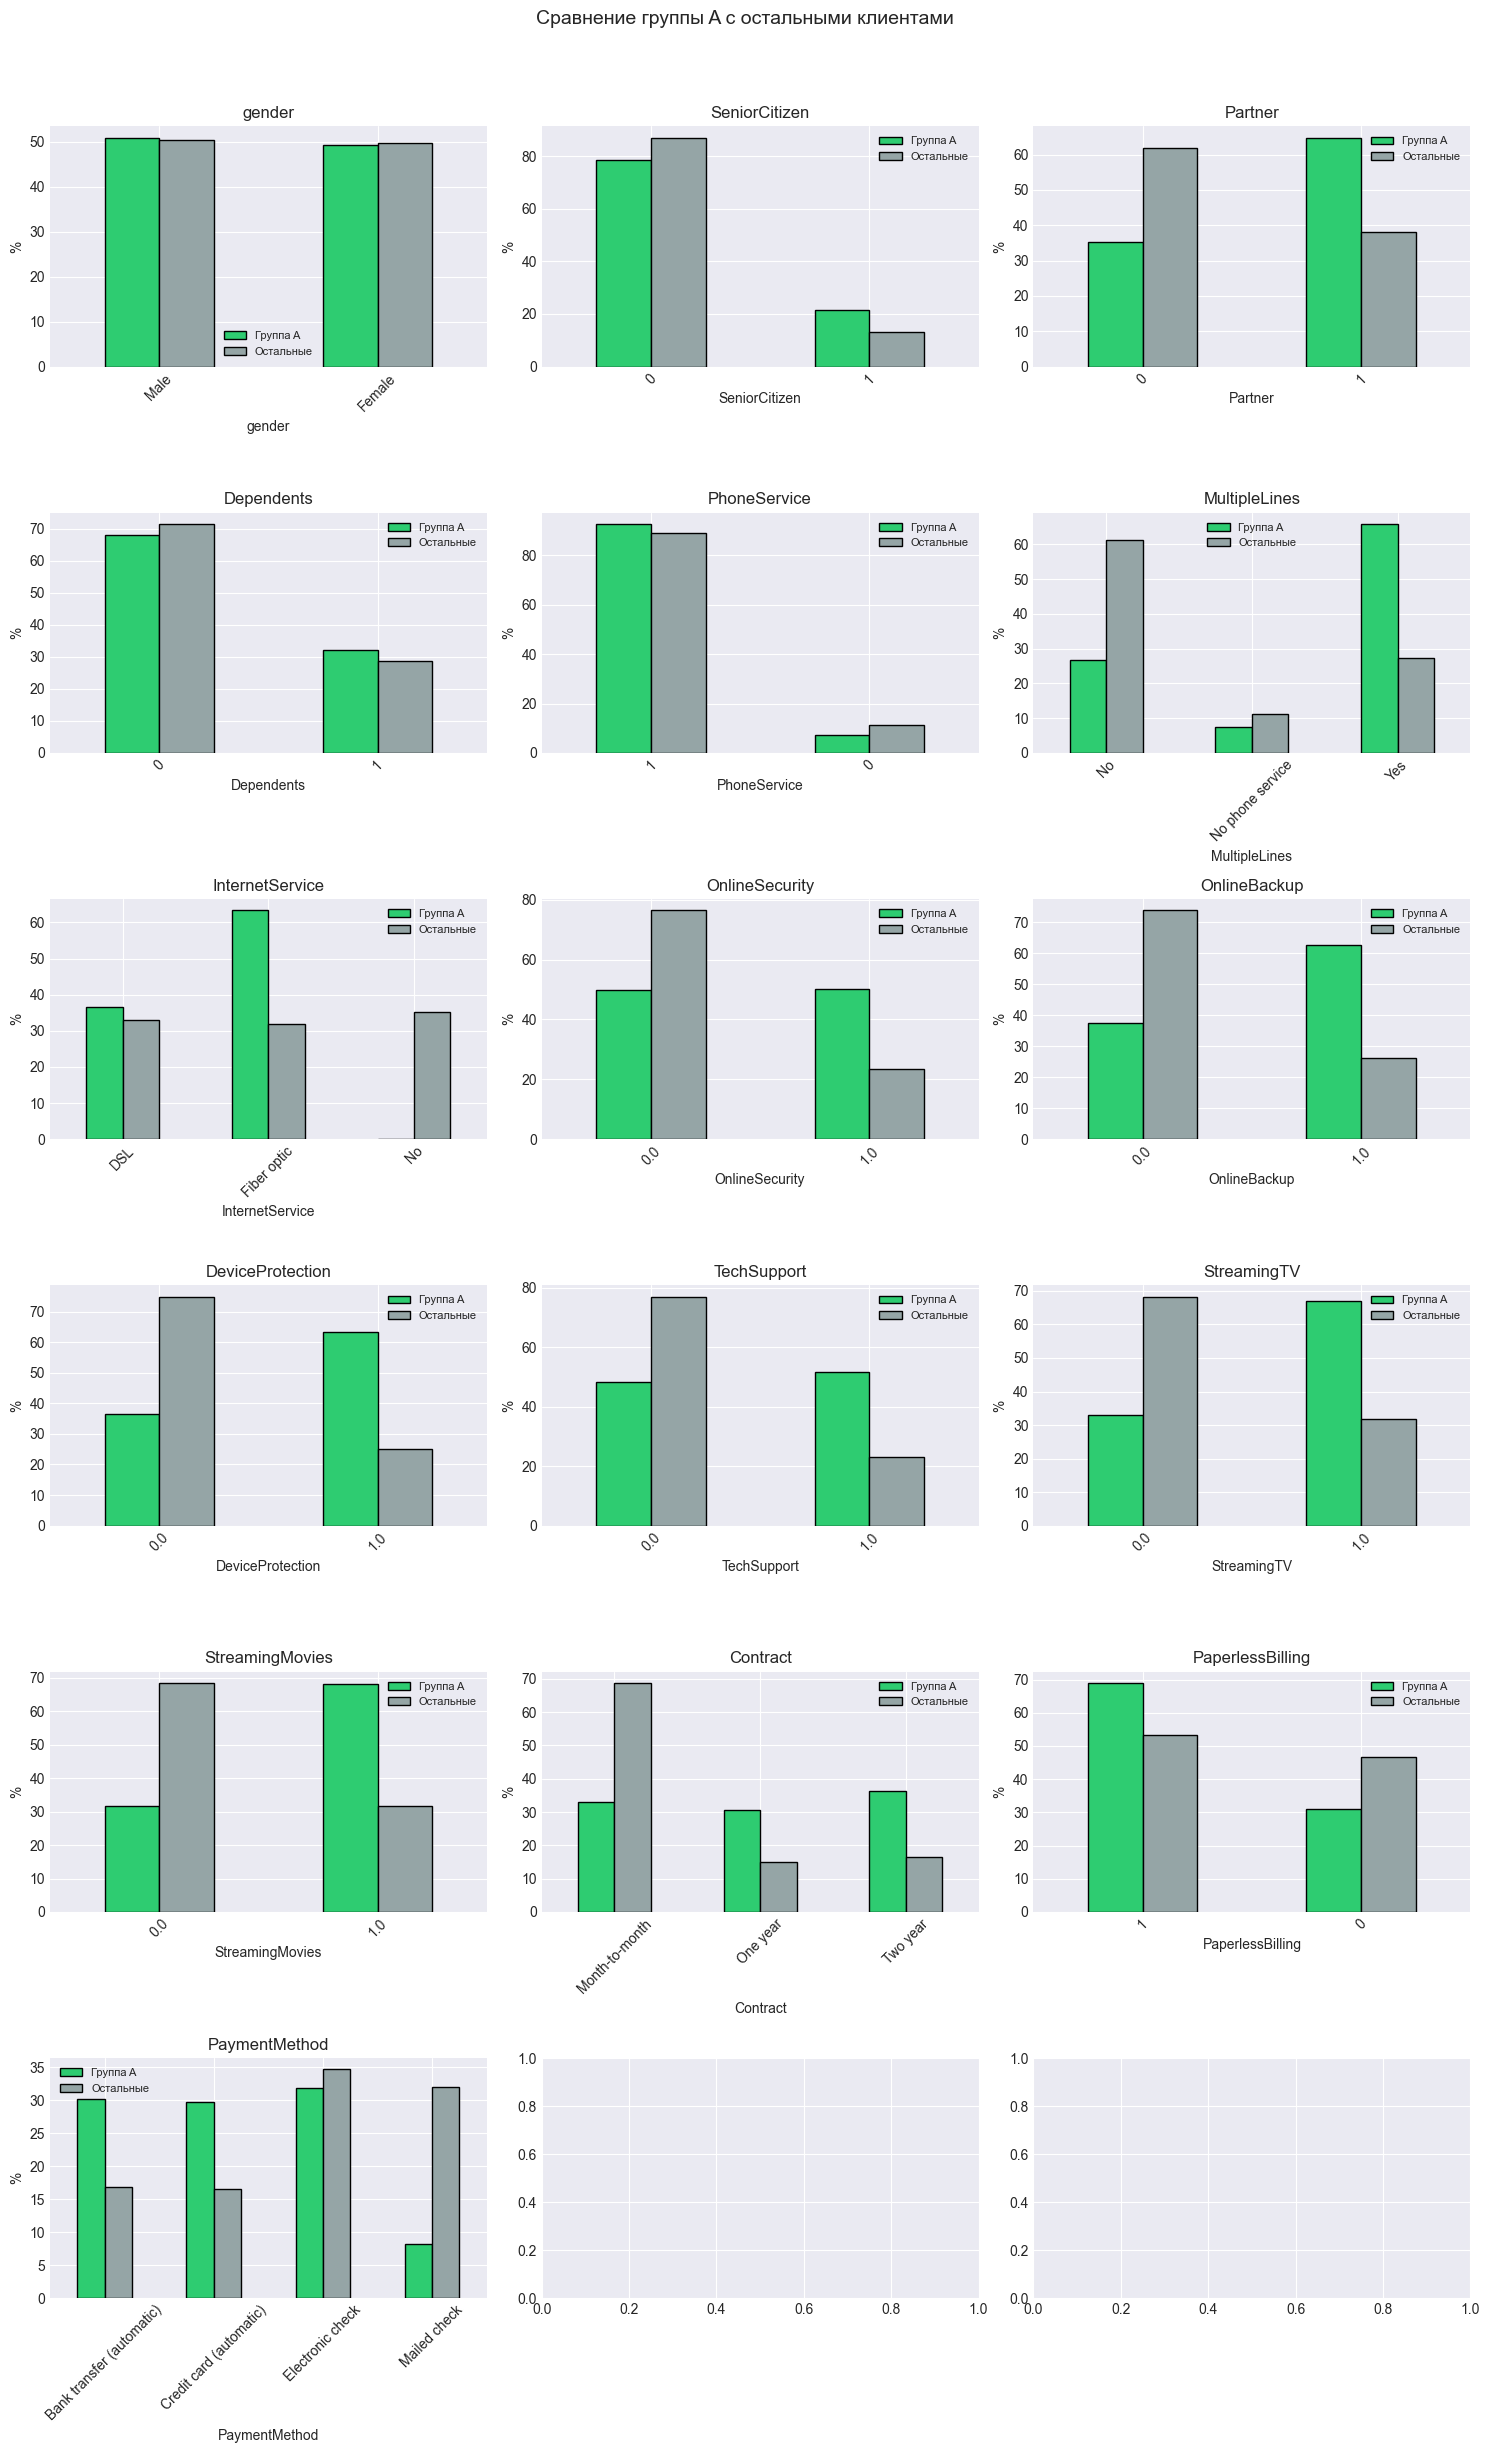

In [190]:
# Выделяем группы
a_group = df[df['abc_mark'] == 'A'].copy()
not_a_group = df[df['abc_mark'] != 'A'].copy()

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for idx, col in enumerate(cat_cols):
    # Распределение в группе A
    a_dist = a_group[col].value_counts(normalize=True).mul(100)
    # Распределение в остальных
    not_a_dist = not_a_group[col].value_counts(normalize=True).mul(100)

    # Объединяем для сравнения
    comparison = pd.DataFrame({
        'Группа A': a_dist,
        'Остальные': not_a_dist
    }).fillna(0)

    comparison.plot(kind='bar', ax=axes[idx],
                   color=['#2ecc71', '#95a5a6'],
                   edgecolor='black')
    axes[idx].set_title(col)
    axes[idx].set_ylabel('%')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].legend(fontsize=8)

plt.suptitle('Сравнение группы A с остальными клиентами', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [191]:
a_group.groupby(['gender', 'SeniorCitizen', 'Partner', 'Dependents'])['Churn'].sum()

gender  SeniorCitizen  Partner  Dependents
Female  0              0        0             63
                                1              4
                       1        0             44
                                1             44
        1              0        0             39
                                1              0
                       1        0             37
                                1              5
Male    0              0        0             65
                                1              7
                       1        0             59
                                1             38
        1              0        0             27
                                1              0
                       1        0             51
                                1              9
Name: Churn, dtype: int64

## Сегментация по ARPU (MonthlyCharges) + tenure
Делим клиентов на 3 группы по среднемесячному платежу и группы по сроку подписки.

In [192]:
df_charges = df[['customerID', 'tenure', 'MonthlyCharges', 'Churn', 'TotalCharges', 'abc_mark']].copy()
df_charges['ARPU_group'] = pd.qcut(df_charges['MonthlyCharges'], q=3, labels=['low_ARPU', 'medium_ARPU', 'high_ARPU'])
df_charges['tenure_group'] = pd.cut(
    df_charges['tenure'],
    bins=[0, 6, 12, 24, 36, 48, 60, 72],
    labels=['0-6 мес', '6-12 мес', '12-24 мес', '24-36 мес', '36-48 мес', '48-60 мес', '60+ мес']
)


pivot_table = pd.crosstab(
    [df_charges['ARPU_group'], df_charges['tenure_group']],
    df_charges['Churn'],
    normalize='index'
)*100
print("Отток в разрезе ARPU и стажа:")
print(pivot_table.round(1))

Отток в разрезе ARPU и стажа:
Churn                        0     1
ARPU_group  tenure_group            
low_ARPU    0-6 мес       63.0  37.0
            6-12 мес      83.2  16.8
            12-24 мес     89.5  10.5
            24-36 мес     94.8   5.2
            36-48 мес     94.2   5.8
            48-60 мес     95.5   4.5
            60+ мес       98.8   1.2
medium_ARPU 0-6 мес       36.8  63.2
            6-12 мес      64.8  35.2
            12-24 мес     71.5  28.5
            24-36 мес     82.4  17.6
            36-48 мес     81.9  18.1
            48-60 мес     91.5   8.5
            60+ мес       96.6   3.4
high_ARPU   0-6 мес       22.8  77.2
            6-12 мес      30.9  69.1
            12-24 мес     48.6  51.4
            24-36 мес     60.5  39.5
            36-48 мес     69.1  30.9
            48-60 мес     75.4  24.6
            60+ мес       89.5  10.5


In [193]:
df_charges['ARPU_group'].value_counts()

ARPU_group
low_ARPU       2351
high_ARPU      2347
medium_ARPU    2345
Name: count, dtype: int64

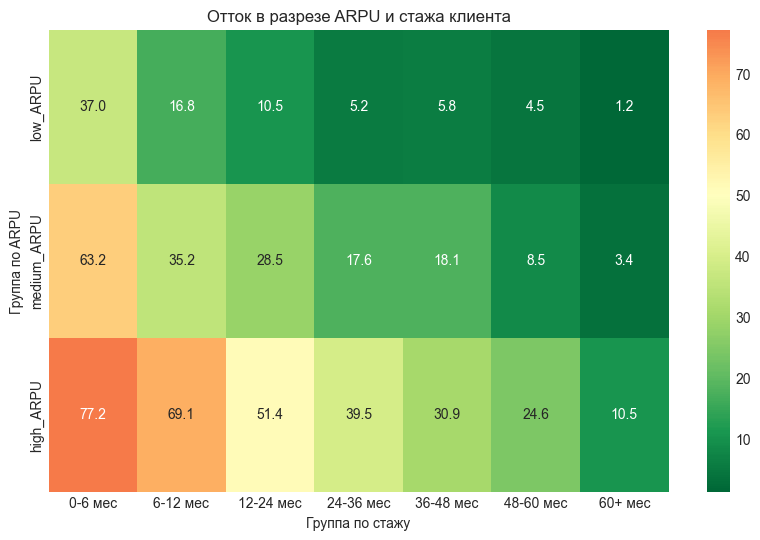

In [194]:
plt.figure(figsize=(10, 6))
pivot_unstack = pivot_table[1].unstack()  # Берем только отток
sns.heatmap(pivot_unstack, annot=True, fmt='.1f', cmap='RdYlGn_r', center=50)
plt.title('Отток в разрезе ARPU и стажа клиента')
plt.ylabel('Группа по ARPU')
plt.xlabel('Группа по стажу')
plt.show()

Наибольший отток наблюдается у клиентов, которые платят выше среднего в первый год и продолжает быть выше остальных групп на протяжении всего периода.

У группы medium самый высокий отток в первые полгода.

Нужно задуматься над удержанием тех, кто готов платить больше или среднюю цену.


## ABC (MonthlyCharges) в разрезе ARPU

In [195]:
df_charges.head()

,customerID,tenure,MonthlyCharges,Churn,TotalCharges,abc_mark,ARPU_group,tenure_group
0,7590-VHVEG,1,29.85,0,29.85,C,low_ARPU,0-6 мес
1,5575-GNVDE,34,56.95,0,1889.50,B,medium_ARPU,24-36 мес
2,3668-QPYBK,2,53.85,1,108.15,C,medium_ARPU,0-6 мес
3,7795-CFOCW,45,42.30,0,1840.75,B,low_ARPU,36-48 мес
4,9237-HQITU,2,70.70,1,151.65,C,medium_ARPU,0-6 мес


In [196]:
df_charges = df_charges.sort_values(by='MonthlyCharges', ascending=False)
df_charges['cumulative_sum'] = df_charges.MonthlyCharges.cumsum()
df_charges['cumulative_share'] = df_charges['cumulative_sum'] / df_charges['MonthlyCharges'].sum()*100
df_charges['abc_mark_monthly'] = df_charges['cumulative_share'].apply(assign_abc_mark)

df_charges.head()

,customerID,tenure,MonthlyCharges,Churn,TotalCharges,abc_mark,ARPU_group,tenure_group,cumulative_sum,cumulative_share,abc_mark_monthly
4586,7569-NMZYQ,72,118.75,0,8672.45,A,high_ARPU,60+ мес,118.75,0.026035,A
2115,8984-HPEMB,71,118.65,0,8477.60,A,high_ARPU,60+ мес,237.40,0.052048,A
4804,5734-EJKXG,61,118.60,0,7365.70,A,high_ARPU,60+ мес,356.00,0.078050,A
3894,5989-AXPUC,68,118.60,0,7990.05,A,high_ARPU,60+ мес,474.60,0.104052,A
5127,8199-ZLLSA,67,118.35,1,7804.15,A,high_ARPU,60+ мес,592.95,0.130000,A


In [197]:
df_charges.abc_mark_monthly.value_counts()

abc_mark_monthly
A    4224
B    1674
C    1145
Name: count, dtype: int64

In [198]:
cross_marks = pd.crosstab(df_charges['abc_mark'], df_charges['abc_mark_monthly']
                          )
print("Пересечение категорий (Monthly vs Total), кол-во пользователей:\n")
print(cross_marks)

Пересечение категорий (Monthly vs Total), кол-во пользователей:

abc_mark_monthly     A    B    C
abc_mark                        
A                 2480  221    0
B                  785  601  307
C                  959  852  838


In [199]:
charges_pivot_pct = df_charges.pivot_table(
    values='customerID',
    columns='abc_mark',
    index='abc_mark_monthly',
    aggfunc=lambda x: len(x) / len(df_charges) * 100,
    fill_value=0
).round(1)
churn_pivot = df_charges.pivot_table(
    values='Churn',
    columns='abc_mark',
     index='abc_mark_monthly',
     aggfunc='mean',
     fill_value=0
)*100
display(charges_pivot_pct, churn_pivot)


abc_mark,A,B,C
abc_mark_monthly,,,
A,35.2,11.1,13.6
B,3.1,8.5,12.1
C,0.0,4.4,11.9


abc_mark,A,B,C
abc_mark_monthly,,,
A,19.032258,40.127389,62.877998
B,9.049774,8.985025,36.150235
C,0.000000,1.628664,10.978520


In [200]:
total_tenure_pivot = df_charges.pivot_table(
    values='Churn',
    columns='tenure_group',
     index='abc_mark_monthly',
     aggfunc='mean',
     fill_value=0
)*100
monthly_tenure_pivot = df_charges.pivot_table(
    values='Churn',
    columns='tenure_group',
     index='ARPU_group',
     aggfunc='mean',
     fill_value=0
)*100
display(total_tenure_pivot, monthly_tenure_pivot)


tenure_group,0-6 мес,6-12 мес,12-24 мес,24-36 мес,36-48 мес,48-60 мес,60+ мес
abc_mark_monthly,,,,,,,
A,70.072993,51.832461,41.114983,31.528046,25.910064,18.374558,8.543689
B,49.471459,22.340426,20.078740,8.196721,13.294798,8.387097,1.639344
C,22.435897,9.629630,3.571429,1.515152,0.819672,2.702703,0.751880


tenure_group,0-6 мес,6-12 мес,12-24 мес,24-36 мес,36-48 мес,48-60 мес,60+ мес
ARPU_group,,,,,,,
low_ARPU,37.014925,16.849817,10.526316,5.158730,5.833333,4.464286,1.230769
medium_ARPU,63.247863,35.185185,28.455285,17.605634,18.143460,8.536585,3.438395
high_ARPU,77.209302,69.135802,51.360544,39.527027,30.877193,24.585635,10.504775


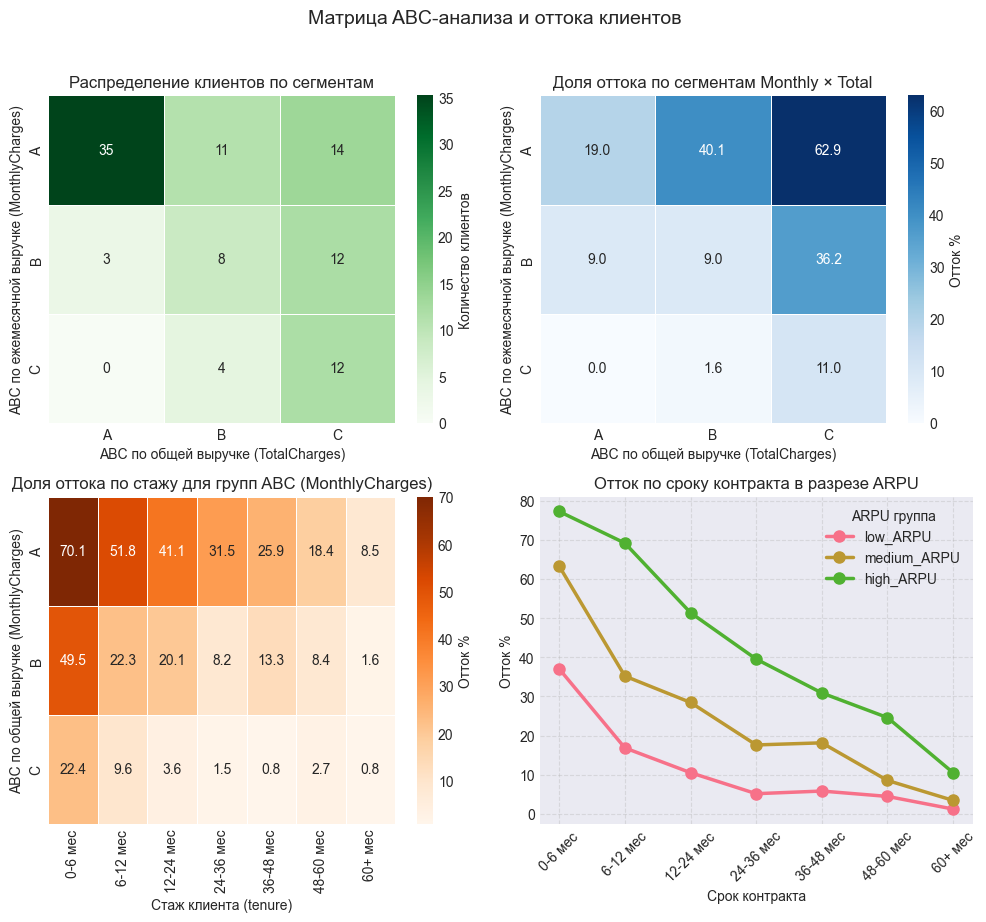

In [201]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10,9))
fig.suptitle('Матрица ABC-анализа и оттока клиентов', fontsize=14, y=1.02)

# График 1
sns.heatmap(charges_pivot_pct, fmt='.0f', annot=True, cmap='Greens',
            ax=ax1, cbar_kws={'label': 'Количество клиентов'}, linewidths=0.5)
ax1.set_title('Распределение клиентов по сегментам')
ax1.set_xlabel('ABC по общей выручке (TotalCharges)')
ax1.set_ylabel('ABC по ежемесячной выручке (MonthlyCharges)')

# График 2
sns.heatmap(churn_pivot, fmt='.1f', annot=True, cmap='Blues',
            ax=ax2, cbar_kws={'label': 'Отток %'}, linewidths=0.5)
ax2.set_title('Доля оттока по сегментам Monthly × Total')
ax2.set_xlabel('ABC по общей выручке (TotalCharges)')
ax2.set_ylabel('ABC по ежемесячной выручке (MonthlyCharges)')

# График 3
sns.heatmap(total_tenure_pivot, fmt='.1f', annot=True, cmap='Oranges',
            ax=ax3, cbar_kws={'label': 'Отток %'}, linewidths=0.5)
ax3.set_title('Доля оттока по стажу для групп ABC (MonthlyCharges)')
ax3.set_xlabel('Стаж клиента (tenure)')
ax3.set_ylabel('ABC по общей выручке (MonthlyCharges)')

# График 4
# sns.lineplot(data=monthly_tenure_pivot, ax=ax4, x='tenure_group', hue='ARPU_group')
# Транспонируем, чтобы срок был по оси X, а ARPU — линии
plot_data = monthly_tenure_pivot.T  # теперь строки = tenure_group, колонки = ARPU_group
for arpu in plot_data.columns:
    plt.plot(plot_data.index, plot_data[arpu],
             marker='o', linewidth=2.5, markersize=8, label=arpu)
ax4.set_title('Отток по сроку контракта в разрезе ARPU')
ax4.set_xlabel('Срок контракта')
ax4.set_ylabel('Отток %')
ax4.legend(title='ARPU группа')
ax4.grid(True, alpha=0.3, color='darkgrey', linestyle='--')
ax4.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Комментарии и выводы к графикам
По первому графику:
1. категория С-А составляет 0%, а С-В -- 4%, значит пользователи с дешевыми тарифами не могут повлиять на существенную часть выручки.  
2. Больше всего денег приносят вип клиенты АА и другие их подкатегории, то есть с высокой помесячной оплатой А.   

По втором графику:
1. Самый высокий отток в категории АС -- это клиенты с высокой помесячной оплатой, но у них низкий общий вклад, значит они уходят быстро. В категории В ежемесячной платы то же самый высокий отток среди новых клиентов. 
2. ВИП-клиенты уходят на протяжении всего срока подписки.
3. Самые стабильные -- клиенты с дешевым тарифом. 

Третий и четвертый график с разбивкой по группам ARPU в соотношении со сроком пользования подтверждают тезисы по первым двумя графикам:
1. Самая высокая доля оттока среди новых (до 6 мес) вип-клиентов - почти 80%.  
2. После 6 месяцев использования отток значительно снижается, особенно среди клиентов категорий В и С.
3. Отток среди вип клиентов снижается не так резко и продолжается на всем протяжении графика


# Комбинированная сегментация

Ранее мы разделили пользователей на группы исходя из общей потраченной на услуги суммы. Однако, ежемесячный вклад может отличаться. Так, если пользователь оплачивает дешевый тарифный план, он может быть постоянным клиентом на протяжении многих лет, но при этом приносить денег компании меньше, чем пользователь, присоединившийся не так давно, но потребляющий больше услуг и приносящий больше денег ежемесячно.

Проверим эту гипотезу.


In [202]:
# Создаем метрику, которая показывает, насколько сильно клиент "тратится" относительно среднего по своей когорте.

# Считаем средний MonthlyCharges для каждой группы по стажу
avg_by_tenure = df_charges.groupby('tenure_group')['MonthlyCharges'].transform('mean')

# Создаем индекс: платит ли клиент выше или ниже среднего для своего стажа
df_charges['spending_index'] = df_charges['MonthlyCharges'] / avg_by_tenure

# Теперь можно сегментировать по этому индексу
df_charges['spending_category'] = pd.cut(
    df_charges['spending_index'],
    bins=[0, 0.8, 1.2, float('inf')], # 1- это средний +- 20%, значит средний будет 0.8-1.2,
    #   остальное ниже среднего 0-0.8 или выше до +бесконечности
    labels=['Lower', 'Average', 'Higher']
)

# Анализируем отток
spending_analysis = df_charges.groupby('spending_category')['Churn'].agg(['mean', 'count'])
spending_analysis['mean'] = spending_analysis['mean'] * 100
print(spending_analysis.round(1))

                   mean  count
spending_category             
Lower              12.3   2227
Average            19.0   1819
Higher             41.9   2986


In [203]:
pivot = pd.pivot_table(
    df_charges,
    values='Churn',
    index='spending_category',
    columns='abc_mark',
    aggfunc='mean'
) * 100

print("Отток по spending_category и Total группе:")
print(pivot.round(1))

Отток по spending_category и Total группе:
abc_mark              A     B     C
spending_category                  
Lower               6.5   4.7  17.7
Average             9.0  16.8  36.8
Higher             24.9  48.8  70.3


In [204]:
total_churned = df_charges['Churn'].sum()
print(f"Всего ушло клиентов: {total_churned}")

Всего ушло клиентов: 1869


In [205]:
# Таблица 1: spending_category × Total группа
churn__total = pd.pivot_table(
    df_charges,
    values='Churn',
    index='spending_category',
    columns='abc_mark',
    aggfunc='mean'
) * 100
print("Количество ушедших по spending_category × Total:")
print(churn__total.round(1))
churn_counts_total = pd.pivot_table(
    df_charges[df_charges['Churn'] == 1],
    values='customerID',
    index='spending_category',
    columns='abc_mark',
    aggfunc='count',
    fill_value=0
)

churn_pct_total = (churn_counts_total / total_churned * 100).round(1)

print("\nДоля в общем оттоке (%) по spending_category × Total:")
print(churn_pct_total)

Количество ушедших по spending_category × Total:
abc_mark              A     B     C
spending_category                  
Lower               6.5   4.7  17.7
Average             9.0  16.8  36.8
Higher             24.9  48.8  70.3

Доля в общем оттоке (%) по spending_category × Total:
abc_mark              A     B     C
spending_category                  
Lower               0.7   1.9  12.0
Average             4.3   3.3  10.8
Higher             21.3  14.8  30.9


In [206]:
pivot = pd.pivot_table(
    df_charges,
    values='Churn',
    index='spending_category',
    columns='abc_mark_monthly',
    aggfunc='mean'
) * 100

print("Отток по spending_category и Monthly группе от общего числа:")
print(pivot.round(1))

churn_counts_monthly = pd.pivot_table(
    df_charges[df_charges['Churn'] == 1],
    values='customerID',
    index='spending_category',
    columns='abc_mark_monthly',
    aggfunc='count',
    fill_value=0
)

churn_pct_monthly = (churn_counts_monthly / total_churned * 100).round(1)

print("\nДоля в общем оттоке (%) по spending_category × Monthly:")
print(churn_pct_monthly)

Отток по spending_category и Monthly группе от общего числа:
abc_mark_monthly      A     B    C
spending_category                 
Lower               0.0  16.6  8.5
Average            11.5  33.9  NaN
Higher             41.9   NaN  NaN

Доля в общем оттоке (%) по spending_category × Monthly:
abc_mark_monthly      A     B    C
spending_category                 
Lower               0.0   9.4  5.2
Average             7.4  11.0  0.0
Higher             66.9   0.0  0.0


Из этих сводных таблиц мы делаем вывод, что больше всего отписываются те, кто платит выше среднего по своей категории стажа (срока подписки) -- 66% всех отписавшихся или 42% от всех, кто платит выше среднего.   
Higher-C по TotalCharges составляет 30.9% от общего числа оттока, что является очень высоким показатем -- если они оказались в категории С, значит они успели потратить мало денег, значит совсем недолго были среди клиентов. Нужно работать над удержанием этой категории.
Те, кто платит ниже среднего, составляют ту основную массу пользователей, на которых держится бизнес (категория A-Lower), это старожилы.

Мы выяснили, что наша целевая аудитория -- это категория **Higher АВС**. Они тратят денег больше среднего, но и самые нестабильные. Теперь нам нужно составить портрет пользователя и противопоставить в этой категории тех, кто отписался тем кто остался, чтобы найти закономерности и использовать их для удержания клиентов.

## поиск закономерностей в группе Higher по spending

In [208]:
higher = df_charges[df_charges['spending_category']== 'Higher'].copy()


In [209]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'abc_mark'],
      dtype='str')

In [210]:
higher = higher.merge(df[['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']], how='left', on='customerID')
higher.head()

,customerID,tenure_x,MonthlyCharges,Churn,TotalCharges,abc_mark,ARPU_group,tenure_group,cumulative_sum,cumulative_share,...,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
0,7569-NMZYQ,72,118.75,0,8672.45,A,high_ARPU,60+ мес,118.75,0.026035,...,Fiber optic,1.0,1.0,1.0,1.0,1.0,1.0,Two year,1,Bank transfer (automatic)
1,8984-HPEMB,71,118.65,0,8477.60,A,high_ARPU,60+ мес,237.40,0.052048,...,Fiber optic,1.0,1.0,1.0,1.0,1.0,1.0,Two year,1,Electronic check
2,5734-EJKXG,61,118.60,0,7365.70,A,high_ARPU,60+ мес,356.00,0.078050,...,Fiber optic,1.0,1.0,1.0,1.0,1.0,1.0,One year,1,Electronic check
3,5989-AXPUC,68,118.60,0,7990.05,A,high_ARPU,60+ мес,474.60,0.104052,...,Fiber optic,1.0,1.0,1.0,1.0,1.0,1.0,Two year,0,Mailed check
4,8199-ZLLSA,67,118.35,1,7804.15,A,high_ARPU,60+ мес,592.95,0.130000,...,Fiber optic,1.0,1.0,1.0,1.0,1.0,1.0,One year,1,Bank transfer (automatic)


In [211]:
higher_churned = higher[higher['Churn'] == 1].copy() # отписались
higher_stayed = higher[higher['Churn'] == 0].copy() # остались

In [212]:
# Смотрим комбинацию возраста и типа контракта
age_contract = pd.crosstab(
    [higher['SeniorCitizen'], higher['Contract']],
    higher['Churn'],
    normalize='index'
) * 100

print("Отток по возрасту и типу контракта (%):")
print(age_contract[1].unstack().round(1))

Отток по возрасту и типу контракта (%):
Contract       Month-to-month  One year  Two year
SeniorCitizen                                    
0                        54.2      20.2       7.5
1                        59.7      19.7       4.4


In [213]:
age_payment = pd.crosstab(
    [higher['SeniorCitizen'], higher['PaymentMethod']],
    higher['Churn'],
    normalize='index'
) * 100

print("\nОтток по возрасту и способу оплаты (%):")
print(age_payment[1].unstack().round(1))


Отток по возрасту и способу оплаты (%):
PaymentMethod  Bank transfer (automatic)  Credit card (automatic)  \
SeniorCitizen                                                       
0                                   29.3                     22.2   
1                                   29.2                     37.9   

PaymentMethod  Electronic check  Mailed check  
SeniorCitizen                                  
0                          51.7          37.2  
1                          56.3          60.0  


In [214]:
age_tenure = pd.crosstab(
    [higher['SeniorCitizen'], higher['tenure_group']],
    higher['Churn'],
    normalize='index'
) * 100

print("\nОтток по возрасту и длительности подписки (%):")
print(age_tenure[1].unstack().round(1))


Отток по возрасту и длительности подписки (%):
tenure_group   0-6 мес  6-12 мес  12-24 мес  24-36 мес  36-48 мес  48-60 мес  \
SeniorCitizen                                                                  
0                 72.1      58.8       42.9       32.1       25.2       22.5   
1                 75.5      69.4       56.7       49.1       44.2       28.9   

tenure_group   60+ мес  
SeniorCitizen           
0                 12.7  
1                 13.3  


## Проверка и анализ подключенных услуг 

Мы видим, что график будет перегружен за счет поля 'no internet service', показатель которого везде одинаков. Нужно преобразовать данные так, чтобы они не влияли на подсчет долей.
Для начала проверим, правильно ли у нас указаны данные и 'no internet service' стоит одинаково во всех колонках с услугами и согласуется с информацией об интернет-сетях

In [215]:
service_check = higher[['InternetService', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV',
                    'StreamingMovies']].copy()
total = 0
for service in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']:

    # Находим строки, где InternetService='No' но услуга не 'No internet service'
    mask = (service_check['InternetService'] == 'No') & \
           (service_check[service] != 'No internet service')
    no_service = mask.sum()
    if no_service > 0:
        print(f"в сервисе {service} найдено {no_service} несоответствий")
    total += no_service
print(f"всего найдено {total} несоответствий")


всего найдено 0 несоответствий


Проверка показала, что если указано, что интернета нет, то и в остальных колонках по доп услугам это проставлено аналогично и корректно. Теперь можно в анализе оттока по доп услугам считать только тех людей, у кого есть интернет.
Сделаем визуализацию, чтобы понять, у какой услуги наибольшая разница в оттоке между подключившими и не подключившими услугу

Для пожилых особенно важна тех.поддержка и безопасность -- подключение этих услуг существенно снижает процент оттока, а вот стриминговые фильмы и тв не являются для пользователей чем-то особенным, скорее всего конкуренты могут предложить аналогичные условия.


Теперь рассмотрим мобильную связь.

## Сравнение динамики поведения пользователей по возрасту

Наличие партнера и/или иждивенца существенно снижает вероятность отписки для обоих категорий - пожилых и непожилых.

In [220]:
df1 = higher[['tenure_group', 'SeniorCitizen', 'PaymentMethod', 'Contract', 'gender', 'Churn']]\
    .rename(columns={
    'tenure_groups': 'срок_подписки', 'MonthlyCharges_groups': 'ежемес.платеж',
    'SeniorCitizen': 'пожилые', 'PaymentMethod': 'способ_оплаты',
    'Contract': 'срок_договора', 'gender': 'пол', 'Churn': 'отток'
})
df1

,tenure_group,пожилые,способ_оплаты,срок_договора,пол,отток
0,60+ мес,0,Bank transfer (automatic),Two year,Female,0
1,60+ мес,0,Electronic check,Two year,Female,0
2,60+ мес,0,Electronic check,One year,Female,0
3,60+ мес,0,Mailed check,Two year,Female,0
4,60+ мес,0,Bank transfer (automatic),One year,Male,1
...,...,...,...,...,...,...
2981,0-6 мес,0,Electronic check,Month-to-month,Female,1
2982,0-6 мес,0,Electronic check,Month-to-month,Male,1
2983,0-6 мес,0,Bank transfer (automatic),Month-to-month,Female,1
2984,0-6 мес,0,Electronic check,Month-to-month,Male,1


## Анализируем, на каком сроке и каком типе договора чаще всего отписываются

In [221]:
# Создаем сводную таблицу, чтобы выявить, на каком сроке чаще всего отписываются
pivot = pd.pivot_table(
    df1,
    values='отток',
    index='срок_подписки',
    aggfunc=['sum', 'count', lambda x: (x.sum() / len(x) * 100).round(2)]
)

# Переименовываем колонки для понятности
pivot.columns = ['сумма_оттока', 'всего_подписок', 'доля_оттока_%']
print(pivot)

KeyError: 'срок_подписки'

In [ ]:
# Создаем сводную таблицу в разрезе способов оплаты
pivot2 = pd.pivot_table(
    df1,
    values='отток',
    index='способ_оплаты',
    aggfunc=['sum', 'count', lambda x: (x.sum() / len(x) * 100).round(2)]
)

# Переименовываем колонки для понятности
pivot2.columns = ['сумма_оттока', 'всего_подписок', 'доля_оттока_%']
print(pivot2)

                           сумма_оттока  всего_подписок  доля_оттока_%
способ_оплаты                                                         
Bank transfer (automatic)           177             604          29.30
Credit card (automatic)             146             570          25.61
Electronic check                    815            1536          53.06
Mailed check                        113             276          40.94


In [ ]:
# Создаем сводную таблицу в разрезе типа продления договора
pivot3 = pd.pivot_table(
    df1,
    values='отток',
    index='срок_договора',
    aggfunc=['sum', 'count', lambda x: (x.sum() / len(x) * 100).round(2)]
)

# Переименовываем колонки для понятности
pivot3.columns = ['сумма_оттока', 'всего_подписок', 'доля_оттока_%']
print(pivot3)

                сумма_оттока  всего_подписок  доля_оттока_%
срок_договора                                              
Month-to-month          1110            1990          55.78
One year                 109             543          20.07
Two year                  32             453           7.06


In [ ]:
# Создаем сводную таблицу в разрезе возраста
pivot4 = pd.pivot_table(
    df1,
    values='отток',
    index='пожилые',
    aggfunc=['sum', 'count', lambda x: (x.sum() / len(x) * 100).round(2)]
)

# Переименовываем колонки для понятности
pivot4.columns = ['сумма_оттока', 'всего_подписок', 'доля_оттока_%']
print(pivot4)

         сумма_оттока  всего_подписок  доля_оттока_%
пожилые                                             
0                 881            2225          39.60
1                 370             761          48.62


Чтобы построить рекомендации по удержанию целевой группы Higher, мы составили портрет уходящего и остающегося клиента, платящего больше среднего:
- Самый надёжный клиент в группе Higher — пожилой, с семьёй (партнёр + иждивенцы), с годовым контрактом и автоплатежом.
- Самый нестабильный — молодой, одинокий, без обязательств, с помесячной оплатой и электронными чеками.

Проверим нашу гипотезу

In [ ]:
df_charges.columns

Index(['customerID', 'tenure', 'MonthlyCharges', 'Churn', 'TotalCharges',
       'abc_mark', 'ARPU_group', 'tenure_group', 'spending_index',
       'spending_category', 'cumulative_sum', 'cumulative_share',
       'abc_mark_monthly'],
      dtype='str')

In [ ]:
df = df.merge(df_charges[['customerID','spending_category']], how='left', on='customerID')

In [ ]:
# Портрет А, стабильный: с партнёром, с иждивенцами, годовой контракт, автоплатёж
portrait_A = df[
    # (df['SeniorCitizen'] == 1) &
    ((df['Partner'] == 1) | (df['Dependents'] == 1)) &
    (df['Contract'].isin(['One year', 'Two year'])) &  # или Two year
    (df['PaymentMethod'].isin(['Bank transfer (automatic)', 'Credit card (automatic)']))
]

print(f" Портрет А (надёжный):")
print(f"   Всего клиентов: {len(portrait_A)}")
print(f"   Доля от всех клиентов: {len(portrait_A)/len(df_charges)*100:.2f}%")
print(f"   Из них в группе Higher: {(portrait_A['spending_category'] == 'Higher').sum()}")
print(f"   Отток в этой группе: {portrait_A['Churn'].mean()*100:.1f}%")
print(f"   Средний MonthlyCharges: {portrait_A['MonthlyCharges'].mean():.2f}")
print(f"   Потерянная выручка (если ушли): {portrait_A[portrait_A['Churn']==1]['MonthlyCharges'].sum()/df['MonthlyCharges'].sum()*100:.2f}% от общей выручки в месяц")

 Портрет А (надёжный):
   Всего клиентов: 1371
   Доля от всех клиентов: 19.47%
   Из них в группе Higher: 440
   Отток в этой группе: 5.1%
   Средний MonthlyCharges: 67.06
   Потерянная выручка (если ушли): 1.32% от общей выручки в месяц


In [ ]:
# Портрет А2: пенсионеры (с любыми условиями)
portrait_A2 = df[
    (df['SeniorCitizen'] == 1)
]

print(f"\n👴 Портрет А2 (пенсионеры):")
print(f"   Всего клиентов: {len(portrait_A2)}")
print(f"   Доля от всех клиентов: {len(portrait_A2)/len(df)*100:.2f}%")
print(f"   Из них в группе Higher: {(portrait_A2['spending_category'] == 'Higher').sum()}")
print(f"   Отток в этой группе: {portrait_A2['Churn'].mean()*100:.1f}%")
print(f"   Средний MonthlyCharges: {portrait_A2['MonthlyCharges'].mean():.2f}")
print(f"   Потерянная выручка: {portrait_A2[portrait_A2['Churn']==1]['MonthlyCharges'].sum()/df['MonthlyCharges'].sum()*100:.2f}%")


👴 Портрет А2 (пенсионеры):
   Всего клиентов: 1142
   Доля от всех клиентов: 16.21%
   Из них в группе Higher: 761
   Отток в этой группе: 41.7%
   Средний MonthlyCharges: 79.82
   Потерянная выручка: 8.42%


In [ ]:
# Портрет С: молодой, без партнёра, без иждивенцев, помесячный контракт, электронные чеки
portrait_C = df[
    (df['SeniorCitizen'] == 0) &
    (df['Partner'] == 0) &
    (df['Dependents'] == 0) &
    (df['Contract'] == 'Month-to-month') &
    (df['PaymentMethod'] == 'Electronic check')
]

print(f"\n Портрет С (нестабильный):")
print(f"   Всего клиентов: {len(portrait_C)}")
print(f"   Доля от всех клиентов: {len(portrait_C)/len(df_charges)*100:.2f}%")
print(f"   Из них в группе Higher: {(portrait_C['spending_category'] == 'Higher').sum()}")
print(f"   Из них в группе C по Total: {(portrait_C['abc_mark'] == 'C').sum()}")
print(f"   Отток в этой группе: {portrait_C['Churn'].mean()*100:.1f}%")
print(f"   Средний MonthlyCharges: {portrait_C['MonthlyCharges'].mean():.2f}")
print(f"   Потерянная выручка (если ушли): {portrait_C[portrait_C['Churn']==1]['MonthlyCharges'].sum()/df['MonthlyCharges'].sum()*100:.2f}% от общей выручки в месяц")


 Портрет С (нестабильный):
   Всего клиентов: 805
   Доля от всех клиентов: 11.43%
   Из них в группе Higher: 516
   Из них в группе C по Total: 517
   Отток в этой группе: 54.4%
   Средний MonthlyCharges: 71.77
   Потерянная выручка (если ушли): 7.24% от общей выручки в месяц


# Выводы исследования

1. Оператор привлекает дорогих клиентов, но плохо удерживает их. Нужно разработать стратегию по удержанию вип-клиентов и средних. 

2. Постоянные клиенты "сидят" на дешевых тарифах и приносят мало денег компании.

3. Группа А (TotalCharges), приносящая 80% прибыли компании и составляющая ~ 40% ее аудитории -- наиболее устойчива к оттоку, доля оттока менее 20%.
Из этого можно сделать вывод, что группа А по TotalCharges состоит большей частью из неновых вип-пользоваталей.

4. Наибольший процент оттока среди клиентов с помесячной оплатой 55.78 и без автооплаты (электронные чеки - 53.06%, почтовые чеки - 40.94%).

5. Подключенные слуги 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport' снижают процент оттока, особенно это заметно на пожилых клиентах.

6. Наличие партнера и/или иждивенца существенно снижает вероятность отписки.


Чтобы построить рекомендации по удержанию целевой группы Higher, мы составили портрет уходящего и остающегося клиента, платящего больше среднего:
- Самый надёжный клиент в группе Higher — с семьёй (партнёр + иждивенцы), с годовым контрактом и автоплатежом.
- Самый нестабильный — молодой, одинокий, без обязательств, с помесячной оплатой и электронными чеками.